<a href="https://colab.research.google.com/github/sunandha2/Urban-Mobility-Intelligence-Uber-Analysis/blob/main/Uber_Pickup_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
df = pd.read_csv("uber-raw-data-apr14[1].csv") # to load data
df.head()# show first rows

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [54]:
import os
os.listdir()

['.config', 'uber-raw-data-apr14[1].csv', 'sample_data']

In [55]:
df.info() # to understaan the data
df.describe() # to understand basic statistics


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [56]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [57]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
# to covert to datetime type

In [58]:
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday

STEP 1: Trips by Hour (Peak Detection)

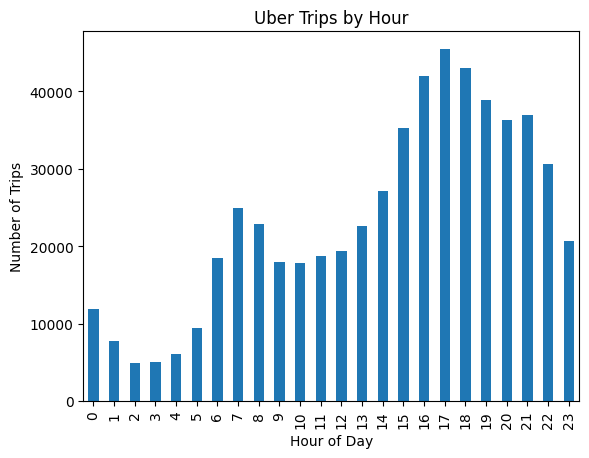

In [59]:
import matplotlib.pyplot as plt

hour_counts = df['hour'].value_counts().sort_index()

hour_counts.plot(kind='bar')
plt.title("Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

Insight:
Uber demand peaks during evening hours, indicating increased ride usage during post-work commuting time.

STEP 2: Trips by Weekday

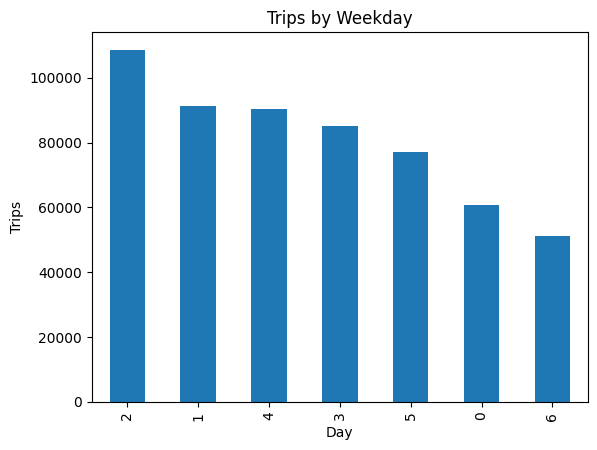

In [60]:
df['weekday'].value_counts().plot(kind='bar')
plt.title("Trips by Weekday")
plt.xlabel("Day")
plt.ylabel("Trips")
plt.show()

Insight:
wednesday show higher demand in weekdays and saturday show higher demand in weekend with monday and sunday having lower demand comparatively

STEP 3: Heatmap

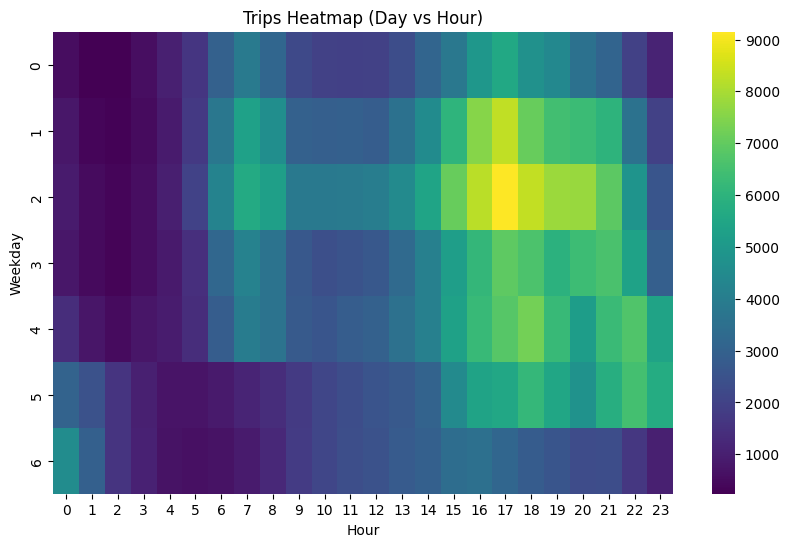

In [61]:
import seaborn as sns

pivot = df.groupby(['weekday', 'hour']).size().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='viridis')

plt.title("Trips Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

Base Analysis

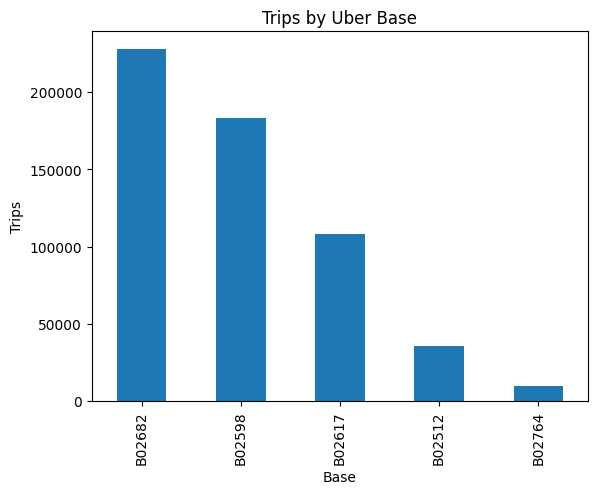

In [62]:
df['Base'].value_counts().plot(kind='bar')
plt.title("Trips by Uber Base")
plt.xlabel("Base")
plt.ylabel("Trips")
plt.show()

The concentration of demand during evening hours suggests an opportunity for dynamic pricing and driver allocation strategies to optimize supply during peak periods.

### Key Insights:
1. Peak demand occurs during 4 PM – 7 PM.
2. Weekdays show sharp commute-driven spikes.
3. Weekend demand is more evenly distributed.
4. Late-night usage increases slightly on weekends.
5. Opportunity for surge pricing and driver optimization during peak hours.

In [63]:
!pip install folium

Create Basic Map

In [64]:
import folium

# NYC location (approx)
map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

map

Plot Sample Data

In [65]:
sample_df = df.sample(1000)

In [66]:
for i in range(len(sample_df)):
    folium.CircleMarker(
        location=[sample_df.iloc[i]['Lat'], sample_df.iloc[i]['Lon']],
        radius=2
    ).add_to(map)

map

In [67]:
import folium
from folium.plugins import HeatMap

# Take sample (important for performance)
sample_df = df.sample(5000)

# Create base map
map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add heatmap
HeatMap(sample_df[['Lat', 'Lon']]).add_to(map)

map

Hour vs Weekday Heatmap

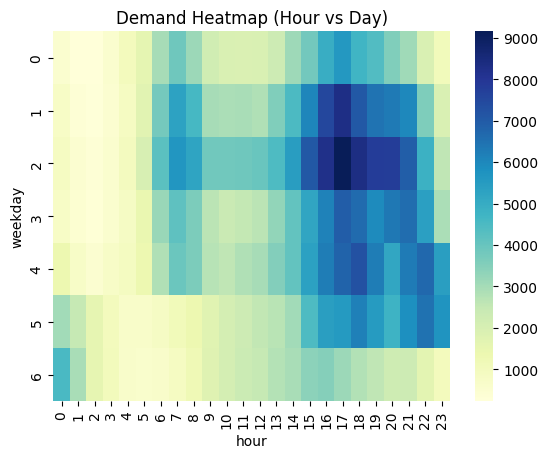

In [68]:
pivot = df.groupby(['weekday', 'hour']).size().unstack()

sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Demand Heatmap (Hour vs Day)")
plt.show()

Base-wise Analysis

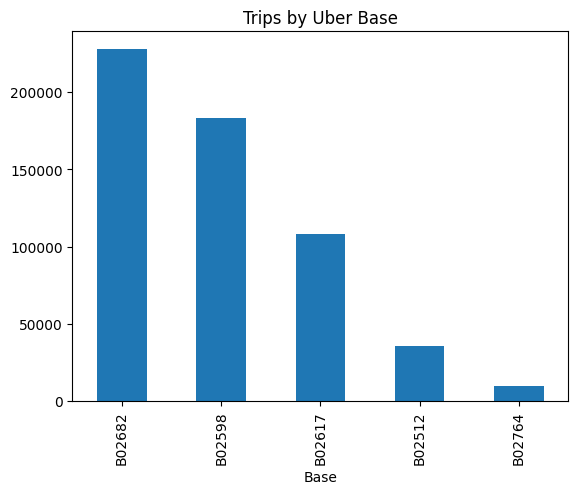

In [69]:
df['Base'].value_counts().plot(kind='bar')
plt.title("Trips by Uber Base")
plt.show()

Insights:B02682 Uber base is most active

Create New Features

In [70]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

Meaning:

1 = weekend
0 = weekday

Create Target Variable

In [71]:
df['demand'] = df['hour'].apply(lambda x: 1 if 16 <= x <= 19 else 0)

1 = high demand (evening peak)
0 = normal demand

Train-Test Split

In [72]:
features = df.groupby(['hour', 'weekday']).size().reset_index(name='rides')

X = features[['hour', 'weekday']]
y = features['rides']

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model (Random Forest) and (LinearRegression)

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [75]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [76]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

print("Linear MAE:", mean_absolute_error(y_test, lr_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression R2: 0.40273078409300056
Random Forest R2: 0.93169657829607
Linear MAE: 1186.964005377216
Random Forest MAE: 362.724411764706


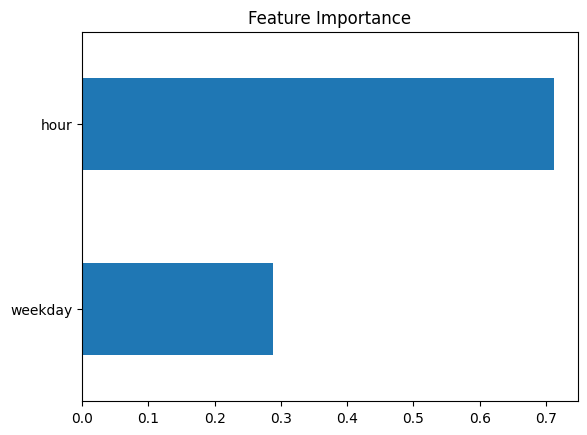

In [77]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

Visualization

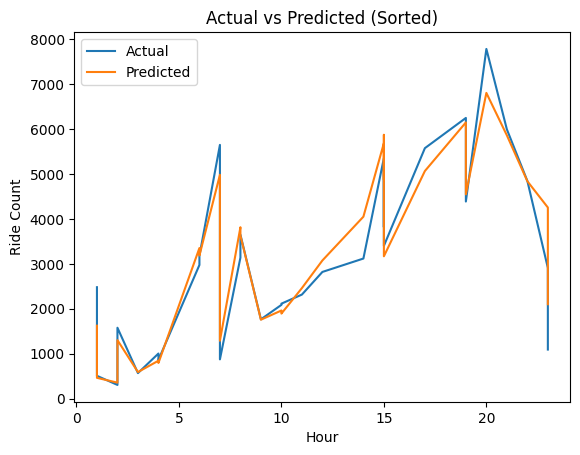

In [79]:
import numpy as np

sorted_idx = np.argsort(X_test['hour'])

plt.plot(X_test['hour'].iloc[sorted_idx], y_test.iloc[sorted_idx], label="Actual")
plt.plot(X_test['hour'].iloc[sorted_idx], rf_pred[sorted_idx], label="Predicted")

plt.xlabel("Hour")
plt.ylabel("Ride Count")
plt.title("Actual vs Predicted (Sorted)")
plt.legend()
plt.show()

Business Insights:
The model can be used to predict high-demand periods and optimize driver allocation.

- Increase drivers during peak hours (4–7 PM)
- Adjust pricing strategies during demand spikes
- Improve service availability in high-demand periods

ML Insights (Start → End Journey)

Initially, I grouped the data by hour to analyze ride demand and built a Linear Regression model using only the hour feature. The model showed poor performance due to limited data (only 24 points) and inability to capture complex patterns.

To improve this, I performed feature engineering by adding weekday along with hour, which increased the dataset size and better represented real-world demand patterns.

I then applied train-test split to ensure proper evaluation and trained two models:
- Linear Regression
- Random Forest Regressor

After comparing both models, Random Forest significantly outperformed Linear Regression, achieving higher accuracy and lower error. This showed that ride demand follows non-linear patterns.

I also visualized actual vs predicted values and analyzed feature importance to understand the impact of different variables.

Overall, this process helped in building a more reliable model capable of predicting peak demand and supporting business decisions like driver allocation and surge pricing.

FINAL SUMMARY

The project demonstrates that incorporating multiple features and using advanced machine learning models significantly improves prediction accuracy.

Random Forest Regressor proved to be the most effective model, capturing complex demand patterns and providing actionable business insights for urban mobility optimization.